In [ ]:
import sys

!{sys.executable} -m pip install matplotlib kagglehub opencv-python scikit-learn scikit-fuzzy

import os
import sys
import shutil  
import kagglehub
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import skfuzzy as fuzz


if not os.path.exists("blood_cell_images"):
    path = kagglehub.dataset_download("paultimothymooney/blood-cells")
    shutil.copytree(path, "blood_cell_images", dirs_exist_ok=True)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Asus\Desktop\DLMI\Brain_Tumor_Segmentation_\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset already exists.


In [2]:
DATASET_DIR = os.path.join(
    os.getcwd(),
    "blood_cell_images",
    "dataset-master",
    "dataset-master"
)

IMAGE_DIR = os.path.join(DATASET_DIR, "JPEGImages")
print("Image directory:", IMAGE_DIR)


Image directory: c:\Users\Asus\Desktop\DLMI\Brain_Tumor_Segmentation_\white_blood_cell_segmentation\blood_cell_images\dataset-master\dataset-master\JPEGImages


In [3]:
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith((".jpg"))
]

print("Total images found:", len(image_files))
print("Sample images:", image_files[:5])


Total images found: 365
Sample images: ['BloodImage_00000.jpg', 'BloodImage_00001.jpg', 'BloodImage_00003.jpg', 'BloodImage_00004.jpg', 'BloodImage_00005.jpg']


In [4]:
from sklearn.cluster import KMeans

def kmeans_segmentation(image, k=4):
    pixels = image.reshape((-1, 3))
    pixels = np.float32(pixels)

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)

    segmented = labels.reshape(image.shape[:2])
    return segmented



In [8]:
import skfuzzy as fuzz

def fcm_segmentation(image, k=4, m=1.8
                     ):
    pixels = image.reshape((-1, 3))
    pixels = np.float32(pixels)

    pixels_T = pixels.T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        pixels_T,
        c=k,
        m=m,
        error=0.005,
        maxiter=1000
    )

    labels = np.argmax(u, axis=0)
    segmented = labels.reshape(image.shape[:2])
    return segmented



In [10]:
from skimage.segmentation import find_boundaries
import numpy as np
import matplotlib.pyplot as plt

def draw_boundaries(segmented, image):

    
    brightness = []
    for i in range(4):
        mask = (segmented == i)
        brightness.append(np.mean(image[mask]))

    
    sorted_clusters = np.argsort(brightness)

   
    # 0 = darkest
    # 1 = 2nd darkest
    # 2 = 3rd darkest
    nucleus_cluster = sorted_clusters[1]
    cytoplasm_cluster = sorted_clusters[2]

    nucleus_mask = (segmented == nucleus_cluster)
    cytoplasm_mask = (segmented == cytoplasm_cluster)

    nucleus_boundary = find_boundaries(nucleus_mask)
    cytoplasm_boundary = find_boundaries(cytoplasm_mask)

    overlay = image.copy()
    overlay[cytoplasm_boundary] = [0, 255, 0]
    overlay[nucleus_boundary] = [255, 0, 0]      # Red → nucleus # Green → cytoplasm

    return overlay


In [11]:
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)


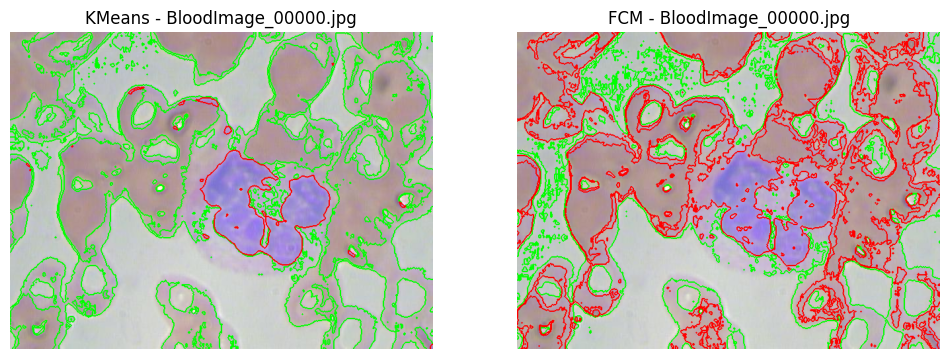

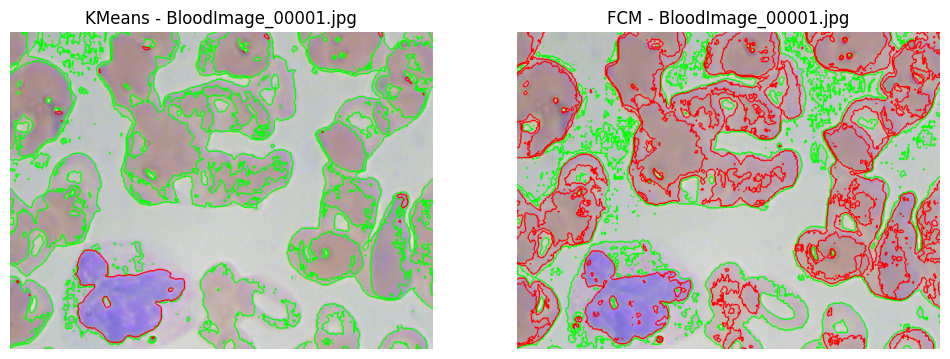

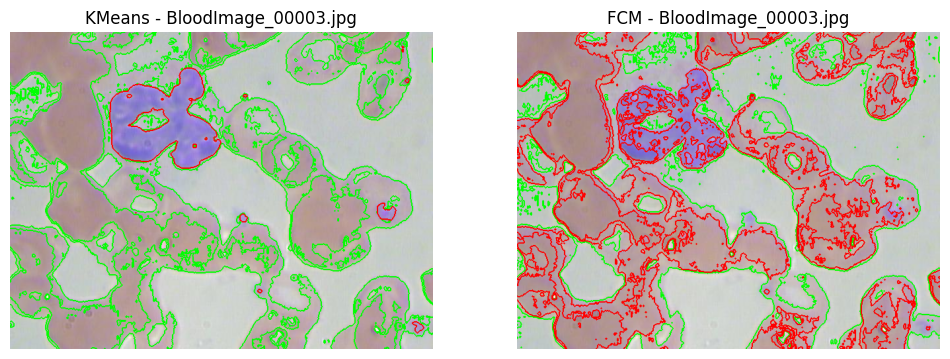

In [ ]:
num_show = 3   

for idx, image_name in enumerate(image_files):

    image_path = os.path.join(IMAGE_DIR, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    
    kmeans_segmented = kmeans_segmentation(img, k=4)
    fcm_segmented = fcm_segmentation(img, k=4)

   
    overlay_k = draw_boundaries(kmeans_segmented, img)
    overlay_f = draw_boundaries(fcm_segmented, img)

   
    if idx < num_show:

        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.imshow(overlay_k)
        plt.title(f"KMeans - {image_name}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(overlay_f)
        plt.title(f"FCM - {image_name}")
        plt.axis("off")

        plt.show()

   
    save_path_k = os.path.join(results_dir, f"kmeans_{image_name}")
    save_path_f = os.path.join(results_dir, f"fcm_{image_name}")

    cv2.imwrite(save_path_k, cv2.cvtColor(overlay_k, cv2.COLOR_RGB2BGR))
    cv2.imwrite(save_path_f, cv2.cvtColor(overlay_f, cv2.COLOR_RGB2BGR))


# Analysis:


For this particular dataset, The k means (hard-clustering ) performs better for nucleus separation. But Fuzzy C means (as we increase m) is not able to separate the various classes (especially the nucleus class) well. However, in some images we can see the cytoplasm is better separated by fuzzy c mean (although it is heavily affected by noise as well) while k means misses it.